In [1]:
# ===================================================
# 설비 이상감지 + 원인분류 실습
# 분석 프로세스
# 1) 정상/이상 설비 데이터 생성
# 2) 주요 영향인자 선정
# 3) 설비 특성 기반 파생변수(치명인자) 생성
# 4) 최적 Indicator 선정
# 5) 치명인자 관계 영향도 그래프 확인
# 6) 머신러닝 기반의 Warning / Critical Threshold 기준 정의
# 7) 이상 원인 진단 분류
# 8) 신규 데이터 이상감지 및 원인분류 테스트
# 9) 도메인 기반 결과 해석
# ===================================================

In [4]:
# ===================================================
# 1. 라이브러리 임포트
# ===================================================
# 기본 라이브러리 
import numpy as np # 수치 계산
import pandas as pd # 표 형태 데이터 처리
import matplotlib.pyplot as plt # 그래프 시각화 처리
import seaborn as sns # 그래프 시각화
import networkx as nx # 변수 간 관계 그래프 그리기

# 머신러닝 라이브러리 
from sklearn.model_selection import train_test_split # 학습/검증 데이터 분리 함수
from sklearn.preprocessing import StandardScaler # 변수 스케일 표준화를 위한 클래스
from sklearn.ensemble import RandomForestClassifier # 랜덤포레스트(원인분류 모델로 사용 예정)
from sklearn.ensemble import IsolationForest # 비지도 이상감지 모델
from sklearn.metrics import classification_report # 분류 성능 리포트 출력
from sklearn.metrics import confusion_matrix # 혼동행렬 계산 함수
from sklearn.metrics import roc_curve # ROC 기반 threshold 탐색
from sklearn.metrics import roc_auc_score # 이상 감지 성능 AUC 계산 함수
from sklearn.inspection import permutation_importance # 변수 중요도 검증 함수
from sklearn.feature_selection import mutual_info_classif # 변수와 이상 여부 간 비선형 관련성 계산

# 경고 라이브러리 (불필요한 경고 제거)
import warnings 
warnings.filterwarnings("ignore")

np.random.seed(42)

In [15]:
# ===================================================
# 2. 설비 데이터 생성 함수
# ===================================================

# 정상 데이터 5000개 생성
# 고장 유형 별 이상 데이터 1000개씩 생성
def generate_machine_data(n_normal=5000, n_abnormal_each=1000):
    # 생성된 데이터를 저장할 빈 리스트
    rows = [] 
    
    # 기본(정상), 마모(bearing_wear), 윤활부족(lubrication_fault), 유압누설(hydraulic_leak)
    fault_type = ["normal","bearing_wear","lubrication_fault","hydraulic_leak"] 

    # 정상과 고장 유형의 이름 데이터 범위 정의 - (EDA 분석을 진행 했다는 가정 하에)
    for fault in fault_type:
        if fault == "normal":
            n = n_normal # 정상 데이터 개수
        else:
            n = n_abnormal_each # 이상 데이터 개수

        for i in range(n): # 각 센서를 하나씩 생성
            # 설비 모터의 회전 수(rpm) 생성: 정상 기준 평균 1,500rpm, 표준편차 40 정상 데이터 생성
            rpm = np.random.normal(1500,40)
            # 설비 부하율(load) 생성: 정상 기준 평균 65, 표준편차 8
            load = np.random.normal(65,8)
            # 유압 압력(pressure) 생성: 정상 기준 평균 120bar, 표준편차 5 (압력의 단위:bar)
            pressure = np.random.normal(120,5)
            # 베어링 또는 구동부 온도 생성: 정상 기준 평균 55도, 표준편차 3
            temp = np.random.normal(55,4)
            # 진동(vibration) RMS 생성: 정상 기준 평균 1.2, 표준편차 0.2
            vibration = np.random.normal(1.2,0.2)
            # 모터 전류(current): 정산 기준 평균 22A(암페어), 표준편차 2
            current = np.random.normal(22,2)
            # 윤활유 점도(oil_viscosity) 생성: 정상 기준 평균 42cSt, 표준편차 3
            oil_viscosity = np.random.normal(42, 3)
            # 유량(flow_rate) 생성: 정상 기준 평균 80L/min, 표준편차 5 
            flow_rate = np.random.normal(80,5)
            # 의미 없는 랜덤 변수-1 생성
            noise_1 = np.random.normal(0,1)
            # 의미 없는 랜덤 변수-2 생성
            noise_2 = np.random.normal(10,5)
            # 의미 없는 랜덤 변수-3 생성
            noise_3 = np.random.normal(0,100)

            #  도메인 고장 메커니즘 정의 - [고장 -> 현상 -> 원인 -> 개선방법]
            if fault == "bearing_wear": # 베어링 마모 고장
                vibration += np.random.normal(1.2,0.25) # 베어링 마모 -> 진동 증가
                temp += np.random.normal(8,2) # 베어링 마모 -> 마찰열 -> 온도 증가
                current += np.random.normal(3,1) # 마찰 증가 -> 모터 전류 증가
            elif fault == "lubrication_fault": # 윤활 불량 고장
                oil_viscosity -= np.random.normal(12,2) # 윤활 불량 - 윤활유 점도 감소
                temp += np.random.normal(10,2) # 윤활 불량 -> 온도 증가
                vibration += np.random.normal(0.7,0.2) # 윤활 불량 -> 진동 증가
                current += np.random.normal(2,0.8) # 마찰 증가 -> 모터 전류 증가
            elif fault == "hydraulic_leak": # 유압 누설 고장
                pressure -= np.random.normal(25,4) # 누설 -> 압력 감소
                flow_rate -= np.random.normal(18,4) # 누설 or 효율 저하 -> 유량 감소
                current += np.random.normal(1.5,0.6) # 보상 운전 -> 전류증가
                load -= np.random.normal(5,2) # 유압 효율 저하 -> 부하 전달력 감소

            # 정상/이상 데이터 구분
            if fault == "normal":
                is_abnormal = 0 # 정상: 0
            else:
                is_abnormal = 1 # 이상: 1

            # 하나의 샘플을 리스트에 추가
            rows.append([rpm, load, pressure, temp, vibration, current, oil_viscosity, flow_rate, noise_1, noise_2, noise_3, is_abnormal, fault])
    
    # 데이터 프레임의 컬럼명 정의
    columns = ["rpm", "load", "pressure", "temp", "vibration", "current", "oil_viscosity", "flow_rate", "noise_1", "noise_2", "noise_3", "is_abnormal", "fault_type"]
    # 리스트 데이터를 DataFrame 으로 변환
    df = pd.DataFrame(rows, columns=columns)

    return df

In [16]:
# ===================================================
# 3. 데이터 생성
# ===================================================
df = generate_machine_data() # 설비 정상/이상 데이터 생성
df.head() # 상위 데이터 5개 확인

,rpm,load,pressure,temp,vibration,current,oil_viscosity,flow_rate,noise_1,noise_2,noise_3,is_abnormal,fault_type
0,1471.978392,66.533638,120.502861,58.070340,1.021287,20.084271,47.488289,82.927172,0.690653,4.919945,6.571670,0,normal
1,1528.982468,80.645379,126.423375,59.475372,1.284664,20.700128,43.870685,87.080794,0.461438,14.799331,234.511886,0,normal
2,1508.993855,59.774948,119.319968,57.581471,1.326364,19.954363,42.451749,84.540363,0.116832,6.232174,-53.859273,0,normal
3,1474.321869,63.921463,125.647709,57.658026,0.993596,17.356659,36.006720,77.353279,-0.107172,8.233366,118.471569,0,normal
4,1537.830730,89.911950,123.233302,63.051240,1.310979,21.461204,35.865057,81.606917,0.188257,9.953702,-110.525717,0,normal


In [17]:
# 고장 유형별 데이터 개수 확인
df["fault_type"].value_counts()

fault_type
normal               5000
bearing_wear         1000
lubrication_fault    1000
hydraulic_leak       1000
Name: count, dtype: int64

In [27]:
# ===================================================
# 4. 주요 영향인자 선정
# ===================================================

# row 데이터 변수 목록 정의
sensor_cols = ["rpm", "load", "pressure", "temp", "vibration", "current", "oil_viscosity", "flow_rate", "noise_1", "noise_2", "noise_3"]

# x와 y 정의
X_sensor = df[sensor_cols] # 센서 변수만 입력 데이터로 선택
y_abnormal = df["is_abnormal"] # 정상/이상 라벨 선택 (y값)

# 영향 인자 판단 방법
# 1) 상관 계수
# 2) mutual information
# 3) 랜덤 포레스트 
# 위와 같은 3가지 중요도로 판단

# 1) x/y 간의 상관관계 판단
# - 각 센서 변수와 이상 여부 간 상관계수 절대값 계산 
# --> 고장과의 선형관계(영향도) 확인 가능. ex) 온도 상승 -> 고장
corr_result = df[sensor_cols+["is_abnormal"]].corr()["is_abnormal"].abs().sort_values(ascending=False)

# 2) x/y 간의 비선형 관계 판단
# - 각 센서 변수와 이상 여부 간 비선형 정보량 계산.
# - 비선형으로 확인하는 이유: 고장은 상승, 급감소의 상태도 있기 때문에 비선형으로 확인해야 한다. 
# - --> ex) 온도 상승 -> 고장 / 온도 급감소 -> 고장
mi_scores = mutual_info_classif(X_sensor, y_abnormal, random_state=42)
# 결과를 Series 형태로 변환 (보기 좋게)
mi_result = pd.Series(mi_scores, index=sensor_cols).sort_values(ascending=False)

# 3) rf 모델 예측 기여도 판단
# 변수 중요도 계산을 위한 RF 모델 생성
rf_for_importance = RandomForestClassifier(n_estimators=300, random_state=42)
# 랜덤 포레스트 기반 row 센서 정상/이상 분류 모델 학습
rf_for_importance.fit(X_sensor, y_abnormal)
# 점수 계산 -> 랜덤 포레스트 모델 기반 변수 중요도 계산 (잘 예측했다면 변수들은 중요도가 높다고 판단)
rf_importance = pd.Series(rf_for_importance.feature_importances_, index=sensor_cols).sort_values(ascending=False)

# 결과를 보기 위해 하나의 표로 만듦
# 상관계수, mutual information, 랜덤포레스트 중요도 결과를 dataframe 으로 통합
importance_df = pd.DataFrame({
    "corr_abs": corr_result.drop("is_abnormal"),
    "mutual_info": mi_result,
    "rf_importance": rf_importance,
})
# 세가지 기준의 순위를 합산하여 종합 점수 계산 (토탈 점수를 매긴 컬럼 추가)
importance_df["total_score"] = (
    importance_df["corr_abs"].rank(ascending=True) +
    importance_df["mutual_info"].rank(ascending=True) +
    importance_df["rf_importance"].rank(ascending=True)
)
# 종합 점수가 높은 순서대로 정렬
importance_df = importance_df.sort_values("total_score", ascending=False) 
importance_df

,corr_abs,mutual_info,rf_importance,total_score
vibration,0.628489,0.279807,0.385862,33.0
temp,0.504560,0.167146,0.135600,29.0
pressure,0.415582,0.137239,0.209483,27.0
current,0.457719,0.117626,0.041318,23.0
oil_viscosity,0.386505,0.112241,0.084680,21.0
flow_rate,0.368240,0.107123,0.120707,20.0
load,0.084638,0.011704,0.006594,15.0
rpm,0.020515,0.010605,0.004357,12.0
noise_1,0.007864,0.000000,0.003933,8.0
noise_3,0.003008,0.000000,0.003835,6.0


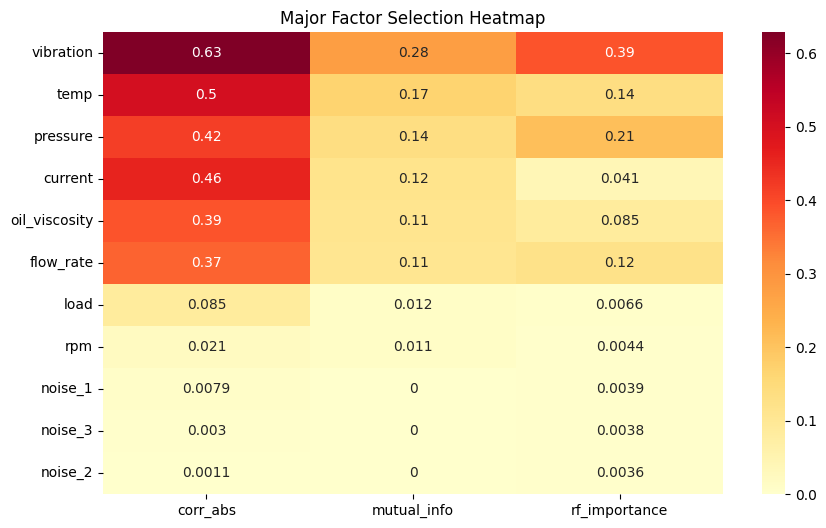

In [31]:
# ===================================================
# 5. 주요 영향인자 히트맵 시각화
# ===================================================
plt.figure(figsize=(10,6))

# 영향 인자 점수를 히트맵으로 표현
sns.heatmap(
    importance_df[["corr_abs", "mutual_info", "rf_importance"]],
    annot= True,
    cmap="YlOrRd"
)

plt.title("Major Factor Selection Heatmap")
plt.show()

In [42]:
# ===================================================
# 6. 설비 특성 기반의 파생변수(치명인자) 생성 (row 기준)
# ===================================================

# 파생변수 함수 생성
def add_critical_features(df):
    # 원본 날라가면 안되니까 원본 보호하기 위해 복사본 생성
    df = df.copy() 

    # 1. 열-전류(상관관계 밀접했던 관계) 스트레스 지수 생성
    # --> 온도와 전류가 높고, 회전수가 낮으면 부하성 열화 가능성이 높다고 판단
    df["thermal_stress_index"] = df.temp*df.current/(df.rpm+1)

    # 2. 진동/부하 결합 지수 생성
    # --> 부하가 커지면 진동도 커짐 -> 베이링/구동계 이상 가능성이 커진다고 판단
    # - 부하가 커도 진동이 낮을수도 있다 온도가 높은데 전류가 낮은 경우도 있다.
    # - 그래서 결합 지수를 만드는 것이다. 하지만 고장 시나리오에 맞춰 지수를 만듦
    df["vibration_load_index"] = df.vibration*df.load # 진동과 부하를 곱한 값

    # 3. 유압 효율 지수 생성
    # --> 같은 전류가 나오는데, 압력과 유량이 낮으면 효율 저하 가능성이 있다고 판단.
    df["hydraulic_efficiency_index"] = df.pressure*df.flow_rate/(df.current+1)

    # 4. 윤활 열화 지수 생성
    # --> 온도가 높고, 점도가 낮으면 윤활 불량 가능성이 높다고 판단.
    df["lubrication_degradation_index"] = df.temp/(df.oil_viscosity+1)

    # 5. 압력-유량 균형 지수 생성
    # - 모든 설비는 압력에 의해.. 압력은 유량이 잘 공급돼야 됨 + 압력 없으면 설비 안돌아감
    # --> 유압 시스템에서 압력과 유량의 비정상 관계를 확인하기 위한 지표
    df["pressure_flow_balance"] = df.pressure/(df.flow_rate+1)

    # 6. 기계 마찰 지수 생성
    # --> 전류와 진동이 동시에 높으면 마찰 또는 정렬 불량 가능성이 있다고 판단.
    df["mechanical_friction_index"] = df.current*df.vibration/(df.load+1)

    # 7. 에너지 손실 지수 생성
    # --> 전류는 높은데 압력이 낮으면 에너지 손실 또는 누설 가능성이 있다고 판단.
    df["energy_loss_index"] = df.current/(df.pressure+1)

    return df

# 파생변수 추가한 DataFrame 저장
df_feat = add_critical_features(df)
critical_cols = ["thermal_stress_index","vibration_load_index","hydraulic_efficiency_index","lubrication_degradation_index", "pressure_flow_balance", "mechanical_friction_index", "energy_loss_index"]

df_feat.head()

,rpm,load,pressure,temp,vibration,current,oil_viscosity,flow_rate,noise_1,noise_2,noise_3,is_abnormal,fault_type,thermal_stress_index,vibration_load_index,hydraulic_efficiency_index,lubrication_degradation_index,pressure_flow_balance,mechanical_friction_index,energy_loss_index
0,1471.978392,66.533638,120.502861,58.070340,1.021287,20.084271,47.488289,82.927172,0.690653,4.919945,6.571670,0,normal,0.791797,67.949938,473.953380,1.197616,1.435803,0.303727,0.165299
1,1528.982468,80.645379,126.423375,59.475372,1.284664,20.700128,43.870685,87.080794,0.461438,14.799331,234.511886,0,normal,0.804681,103.602180,507.326394,1.325484,1.435311,0.325710,0.162452
2,1508.993855,59.774948,119.319968,57.581471,1.326364,19.954363,42.451749,84.540363,0.116832,6.232174,-53.859273,0,normal,0.760931,79.283359,481.396321,1.325182,1.394897,0.435488,0.165844
3,1474.321869,63.921463,125.647709,57.658026,0.993596,17.356659,36.006720,77.353279,-0.107172,8.233366,118.471569,0,normal,0.678327,63.512137,529.467936,1.558042,1.603605,0.265637,0.137047
4,1537.830730,89.911950,123.233302,63.051240,1.310979,21.461204,35.865057,81.606917,0.188257,9.953702,-110.525717,0,normal,0.879340,117.872721,447.736014,1.710325,1.491804,0.309477,0.172749


In [43]:
df_feat.columns

Index(['rpm', 'load', 'pressure', 'temp', 'vibration', 'current',
       'oil_viscosity', 'flow_rate', 'noise_1', 'noise_2', 'noise_3',
       'is_abnormal', 'fault_type', 'thermal_stress_index',
       'vibration_load_index', 'hydraulic_efficiency_index',
       'lubrication_degradation_index', 'pressure_flow_balance',
       'mechanical_friction_index', 'energy_loss_index'],
      dtype='object')

hydraulic_efficiency_index       0.219991
mechanical_friction_index        0.212128
vibration_load_index             0.174932
energy_loss_index                0.152936
thermal_stress_index             0.119989
lubrication_degradation_index    0.106313
pressure_flow_balance            0.013711
dtype: float64


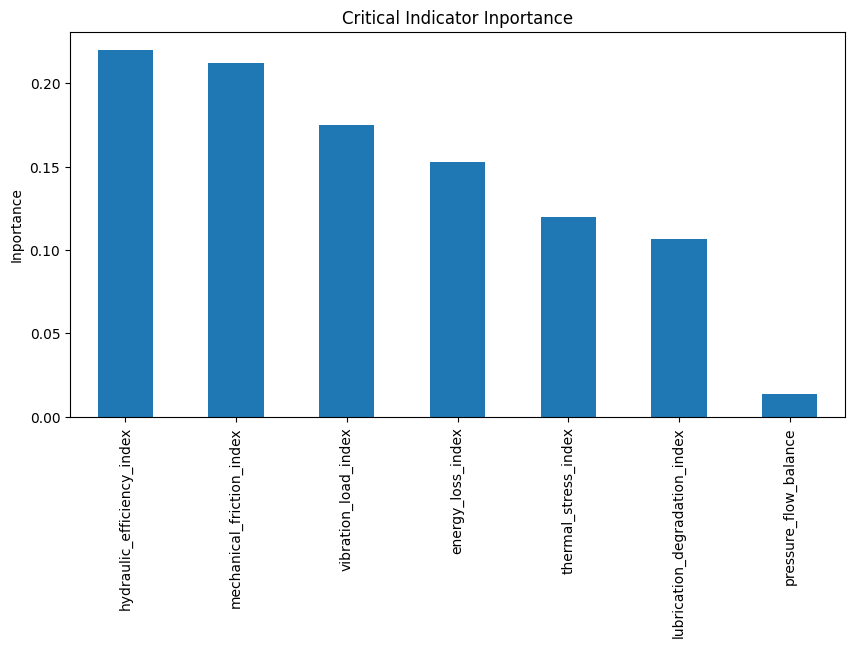

In [45]:
# ===================================================
# 7. 최적 Indicator 선정
# ===================================================

# x: 파생 변수 인자만 입력 변수로 선택
# [참고] df_feat에 데이터를 만들어 뒀었다.
X_critical = df_feat[critical_cols] 

# indicator 모델 생성 (랜덤포레스트)
rf_indicator = RandomForestClassifier(n_estimators=300, random_state=42)
# 파생 변수로 정상/이상 분류 모델 학습
rf_indicator.fit(X_critical, y_abnormal)

# 파생 변수에 대한 중요도 계산
# 피쳐임포턴스를 통해 변수의 중요도를 뽑는다.
indicator_importance = pd.Series(
    rf_indicator.feature_importances_,
    index=critical_cols
).sort_values(ascending=False)
# 치명인자 중요도 출력
print(indicator_importance)

plt.figure(figsize=(10,5))
indicator_importance.plot(kind='bar') # 막대바
plt.title("Critical Indicator Inportance")
plt.ylabel("Inportance")
plt.show()

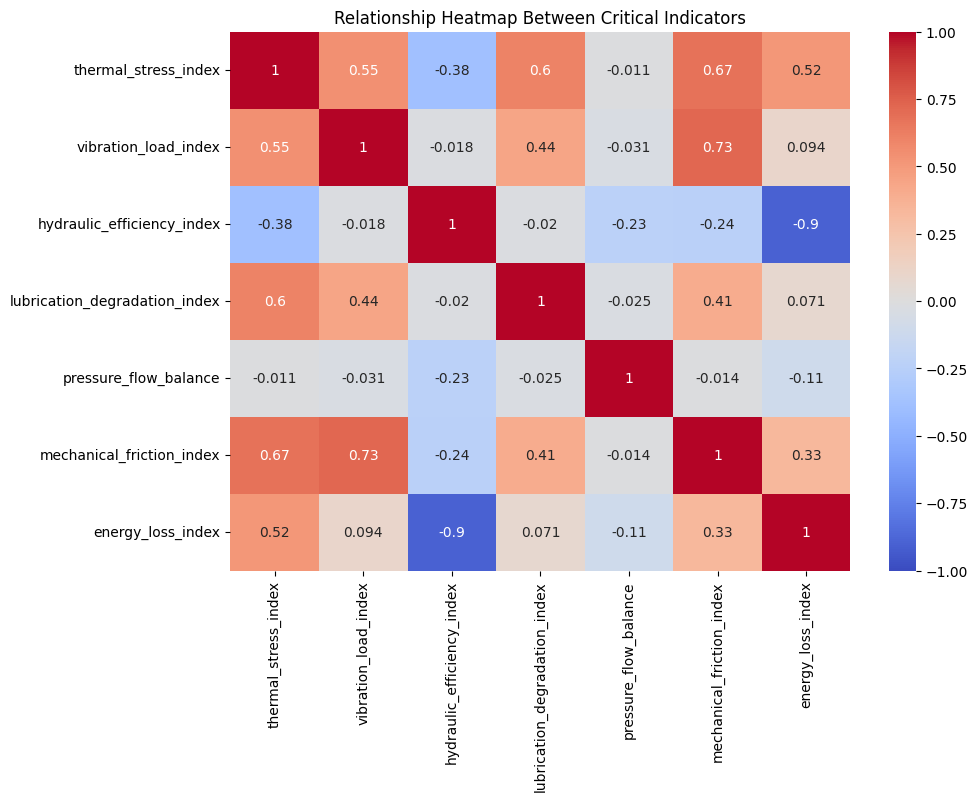

In [48]:
# ===================================================
# 8. 치명인자 간 관계 영향도 그래프
# ===================================================

# 1) 히트맵 
# 치명인자들 간의 상관계수를 계산
critical_corr = df_feat[critical_cols].corr()

# 
plt.figure(figsize=(10,7))

sns.heatmap(
    critical_corr,
    annot= True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Relationship Heatmap Between Critical Indicators")
plt.show()

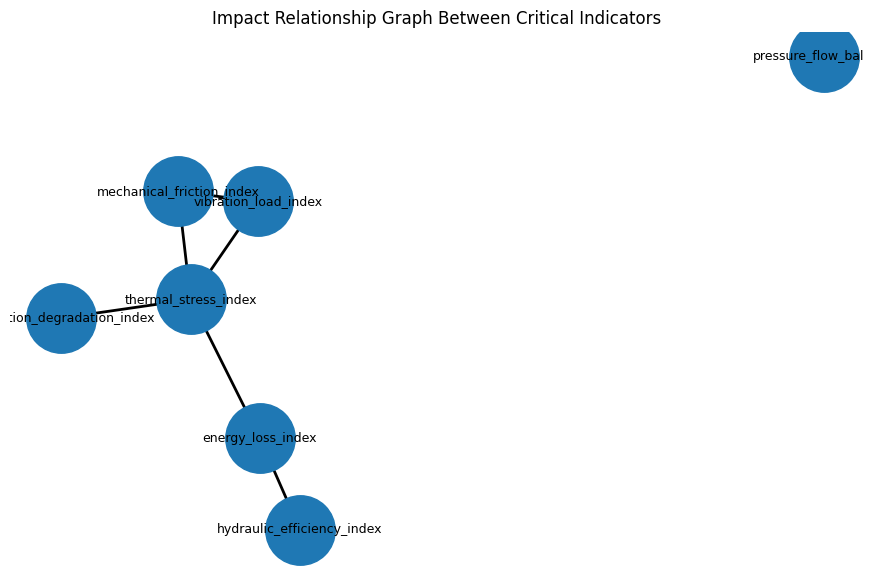

In [49]:
# 치명인자간 얼마나 강하게 연결되어 있는가를 보여주는 네트워크 그래프

# 변수 간 관계 그래프 객체 생성
G = nx.Graph()

# 치명인자 이름을 그래프 노드로 추가
for col in critical_cols:
    G.add_node(col)

# 두 치명인자 간 상관계수 값 추출 및 의미있는 관계 판단
for i in range(len(critical_cols)):
    for ii in range(i+1, len(critical_cols)):
        # 두 치명인자 간 상관계수 값 추출
        corr_value = critical_corr.iloc[i, ii]

        # 상관계수 절대값이 0.45 이상이면 의미있는 관계로 판단
        if abs(corr_value) >= 0.45:
            G.add_edge(
                critical_cols[i],
                critical_cols[ii],
                weight=abs(corr_value)
            )

# 그래프 출력
plt.figure(figsize=(11,7))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=2500) # 변수를 노드로 그리기
nx.draw_networkx_labels(G, pos, font_size=9) # 노드 이름 표시
nx.draw_networkx_edges(G, pos, width=2) # 노드 간 관계선 표시
plt.title("Impact Relationship Graph Between Critical Indicators")
plt.axis("off")
plt.show()

In [50]:
# ===================================================
# 9. 이상감지 모델 학습
# ===================================================

# 정상 데이터만 선택
normal_df = df_feat[df_feat["is_abnormal"] == 0]
# 파생변수(치명인자) 데이터만 선택
X_normal = normal_df[critical_cols]

# 정규화 처리 (데이터의 파생변수들을 표준화)
# - 원래 트리모델에서는 정규화 처리를 안 하는데, 
# - 데이터 중 스케일이 너무 큰 차이가 있는 경우 정규화를 해도 된다)
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal) 

# 아이솔레이션(비지도학습 머신러닝 모델) 모델 사용
iso_model = IsolationForest(
    n_estimators=300, # 트리 개수: 300개
    contamination=0.05, # 학습 정상 데이터 중 이상치로 볼 비율
    random_state=42
)
# 정상 데이터만 사용하여 이상 감지 모델(아이솔레이션 모델) 학습
iso_model.fit(X_normal_scaled)

# 전체 데이터의 치명인자를 정상 기준 스케일로 변환
X_all_scaled = scaler.transform(df_feat[critical_cols])

# Isolation Forest의 decision score 계산
# --> 값이 낮을 수록 이상일 가능성이 높다.
raw_score = iso_model.decision_function(X_all_scaled)

# 해석하기 편하게 값을 변경하는 작업 (값이 클수록 이상이 되도록 부호를 반전)
# --> 정상 0.10, 0.15 / 비정상 0.65, 0.85
df_feat["anomaly_score"] = -raw_score

# 이상 점수와 실제 이상 라벨 기준으로 auc를 계산한다.
# - AUC는 정상 데이터보다 이상 데이터에 더 높은 anomaly score를 줄 확률을 계산하는 것이다.
# --> Threshold 를 정하지 않은 상태에서 이상 점수 자체가 
# --> 정상과 이상을 얼마나 잘 분리하는지 평가하는 지표이다.
auc = roc_auc_score(df_feat.is_abnormal, df_feat.anomaly_score)

print(f"Anomaly Detection AUC: ", auc)

Anomaly Detection AUC:  0.9813502666666667


In [67]:
# ===================================================
# 10. Warning / Critical Threshold 정의 
# ===================================================
'''
# Critical
주의 또는 위험으로 표현해야 함.
그래서 ROC_CURVE를 이용해서 정상과 이상을 가장 잘 구분하는 Critical Threshold를 정의

# Warning
- 정상 데이터 분포의 상위 5% 지점을 Warning Threshold로 정의 
- (정상이지만, 고장 전조 단계이므로 경고)

# Normal -> Warning -> Critical 3단계 위험등급 체계를 구축
'''

# ROC 곡선을 이용하여 threshold 후보들 계산
fpr, tpr, threshold = roc_curve(df_feat.is_abnormal, df_feat.anomaly_score)

# fpr(정상 -> 이상으로 잡은 것) 최소화하기 위해 아래의 알고리즘 사용한다.
# youden_index: 민감도는 높고 가성알람은 낮은 지점을 찾기 위한 기준 (이상을 잘 찾으면서 가성알람은 적은 지점 탐색)
youden_index = tpr-fpr  
# youden_index 가 가장 큰 threshold 위치 저장
best_idx = np.argmax(youden_index)
# Critical 기준 threshold 설정
critical_threshold = threshold[best_idx]

'''
ex)
threshold  TPR  FPR  Youden
0.5 0.95 0.40 0.55
1.0 0.90 0.10 [0.80] <- Youden 가장 큰 값 (이상/정상 가장 잘 구분할 수 있는 기준) / threshold 1.0 이 정상/이상 구분 가장 잘함.
1.5 0.75 0.05 0.70
'''

# 정상 데이터의 이상 점수만 선택 (정상/이상 구분)
# 그래프를 그리기 위해 데이터를 뽑음
normal_score = df_feat[df_feat.is_abnormal==0]["anomaly_score"]
# 정상 데이터 상위 15% 지점을 warning 기준으로 설정
warning_threshold = np.percentile(normal_score, 85)

print("Warning Threshold: ", warning_threshold)
print("Critical Threshold: ", critical_threshold)

# 이상 점수를 입력받아 위험 등급을 반환하는 함수
def classify_risk_level(score, warning_threshold, critical_threshold):
    if score >= critical_threshold:
        return "CRITICAL"
    elif score >= warning_threshold:
        return "WARNING"
    else: 
        return "NORMAL"

# 전체 데이터에 대해 위험 등급 계산
df_feat["risk_level"] = df_feat.anomaly_score.apply(
    lambda x: classify_risk_level(x, warning_threshold, critical_threshold)
)

# 위험 등급별 개수 출력
print(df_feat.risk_level.value_counts())

Warning Threshold:  -0.041227799576053284
Critical Threshold:  -0.019625558999513792
risk_level
NORMAL      4295
CRITICAL    3302
WARNING      403
Name: count, dtype: int64


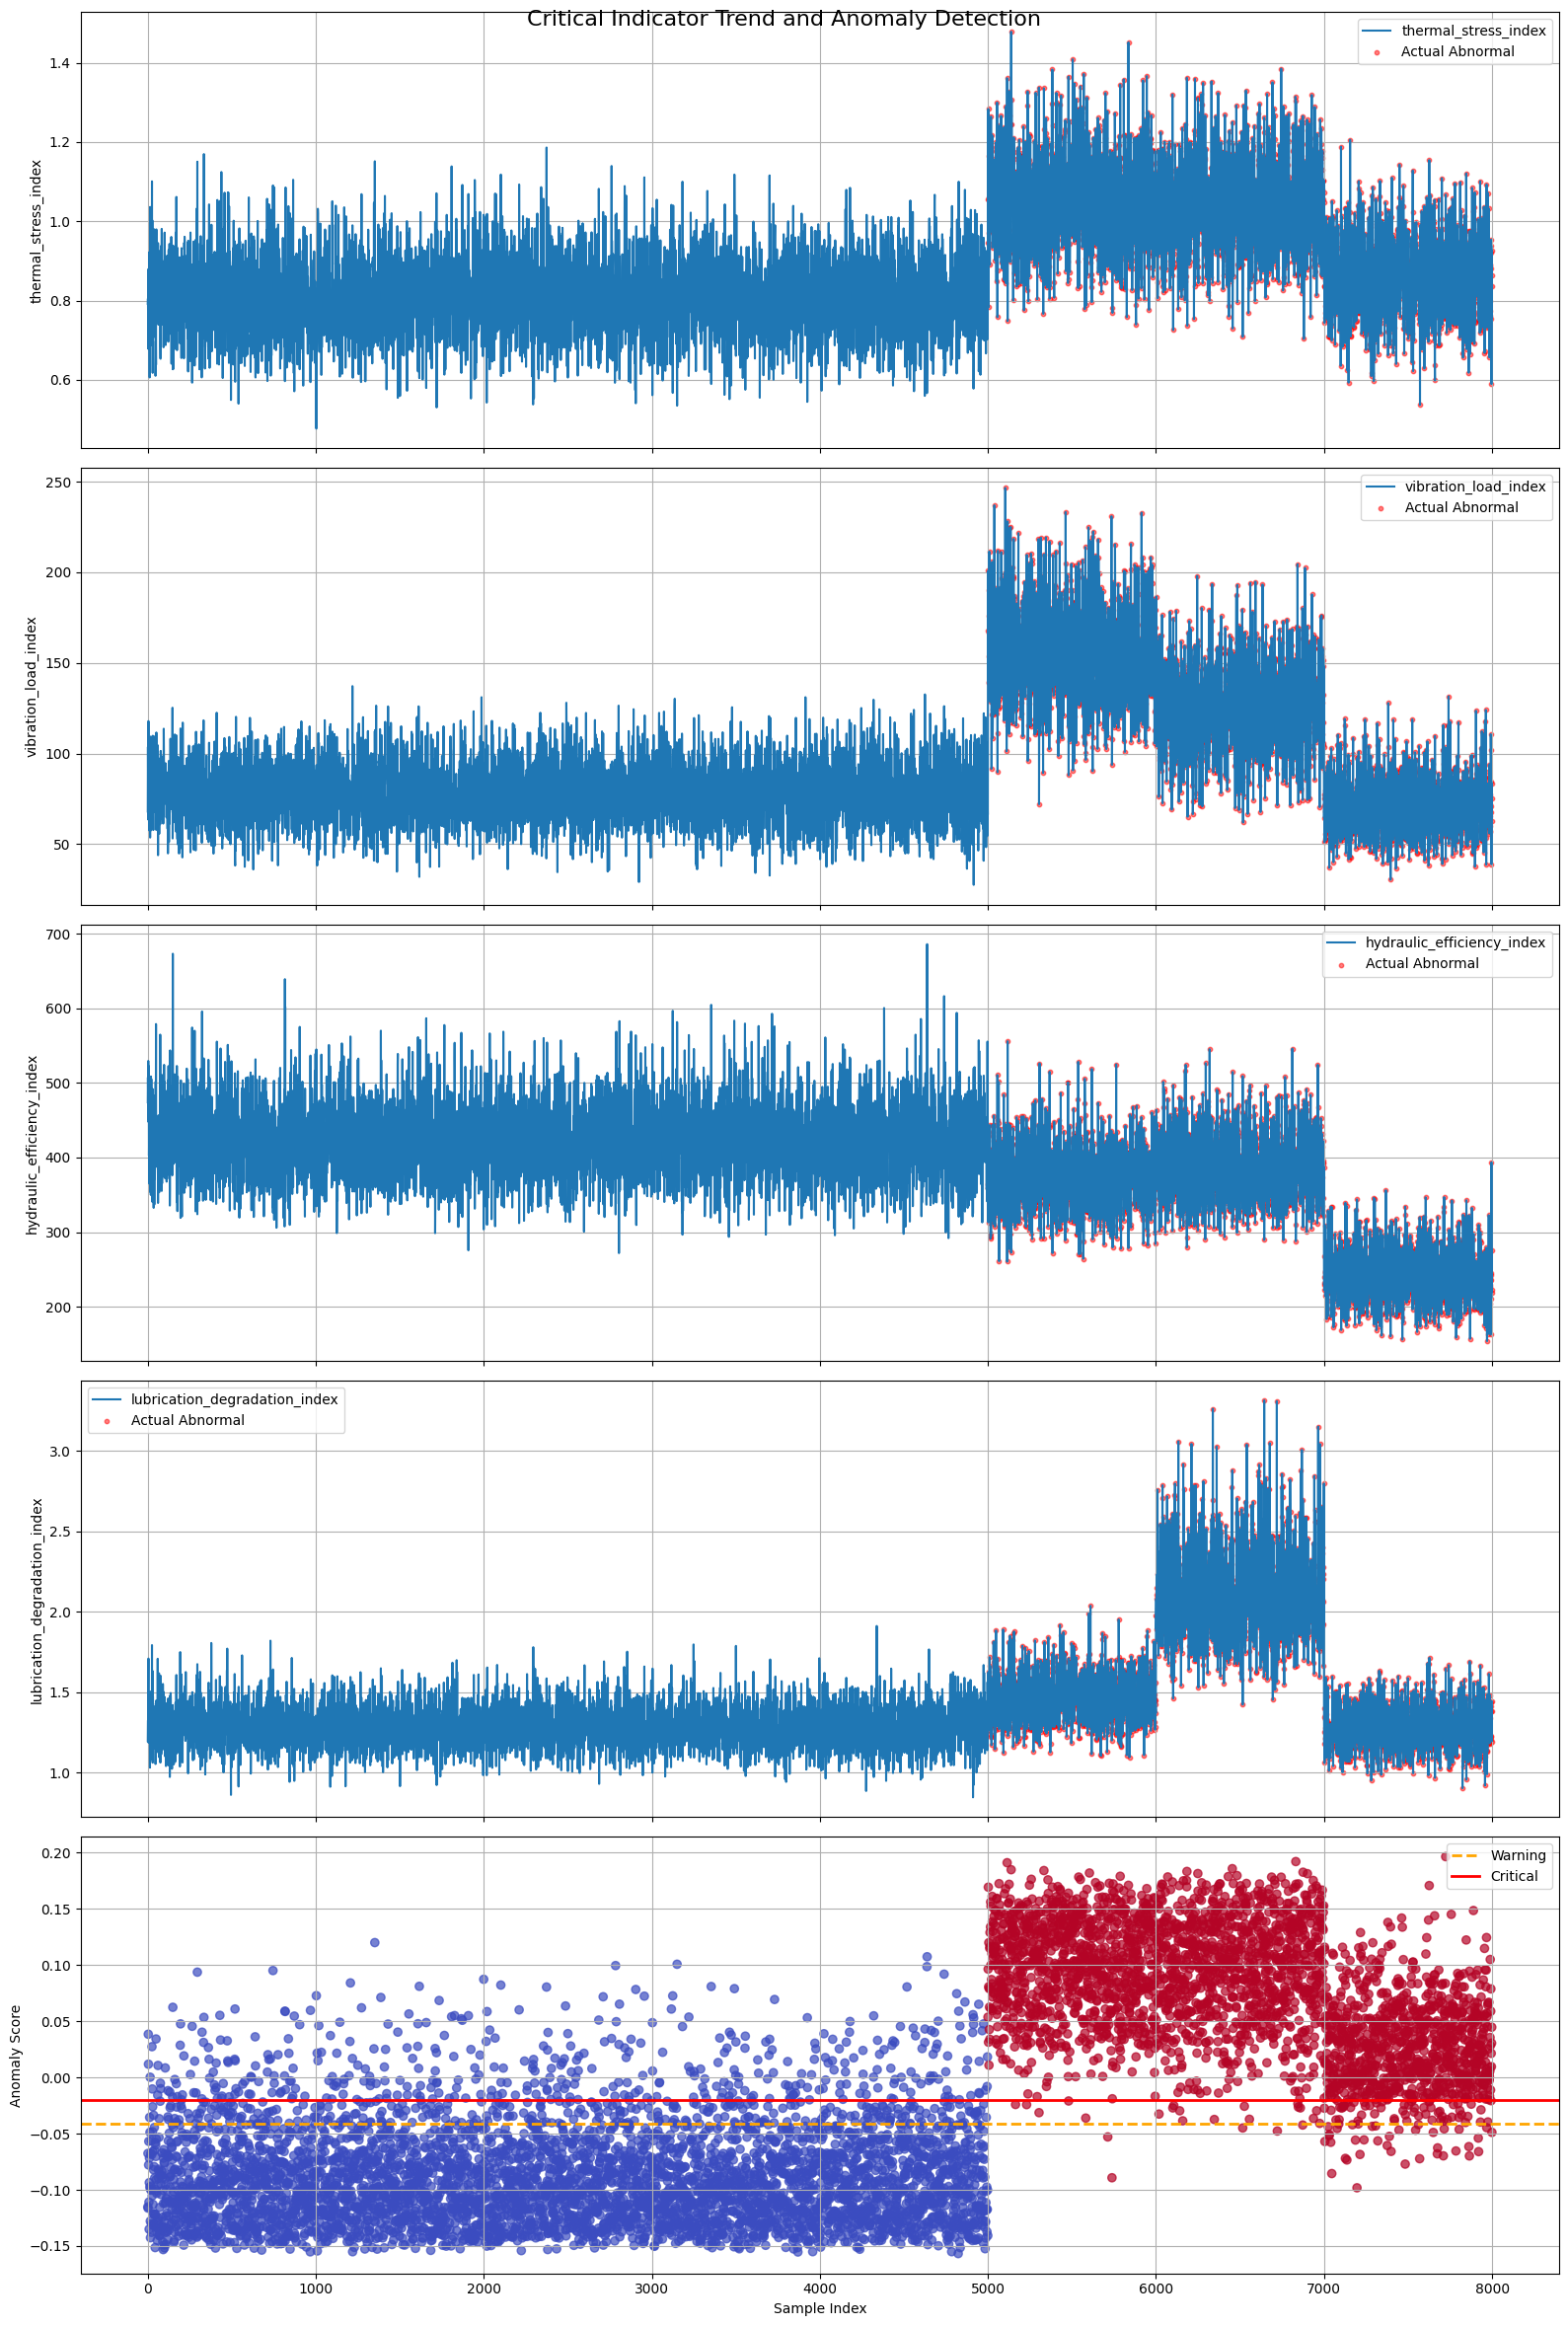

In [68]:
# ===================================================
# 11. 이상 점수를 기준으로 위험 등급 생성 및 그래프 시각화
# ===================================================

# 전체 데이터 스케일링
X_all_scaled = scaler.transform(df_feat[critical_cols])
# 이상 점수 계산
raw_score = iso_model.decision_function(X_all_scaled)

# anomaly score 생성
df_feat["anomaly_score"] = -raw_score
# anomaly score를 warning/critical 기준과 비교해서 normal, warning, critical 등급 생성
df_feat["risk+level"] = df_feat.anomaly_score.apply(
    lambda score: classify_risk_level(score, warning_threshold, critical_threshold)
)

# 치명인자 & 이상데이터 시계열 + 이상 구간 비교 시각화
critical_plot_cols = ["thermal_stress_index","vibration_load_index","hydraulic_efficiency_index","lubrication_degradation_index"]
# 시각화할 치명인자 개수 + 1개(맨 아래 종합용 칸)만큼 세로로 서브플롯 생성
fig, axes = plt.subplots(
    len(critical_plot_cols)+1,
    1,
    figsize=(16,24),
    sharex=True, # sharex=True: 모든 그래프가 x축(인덱스)을 공유하도록 설정
)
# 각 치명인자마다 하나의 서브플롯에 그래프를 그림
for i, col in enumerate(critical_plot_cols):
    # 해당 치명인자 값을 시계열(선 그래프)로 표시
    axes[i].plot(df_feat.index, df_feat[col], linewidth=1.5, label=col)
    # 실제 이상 데이터 표시
    abnormal_idx = df_feat[df_feat.is_abnormal==1].index
    # 이상 데이터 지점을 빨간 점으로 겹쳐 표시 (실제 고장 구간 확인용)
    axes[i].scatter(abnormal_idx, df_feat.loc[abnormal_idx, col], color="red", s=10, alpha=0.5, label="Actual Abnormal")
    axes[i].set_ylabel(col) # y축 라벨을 해당 치명인자 이름으로 설정
    axes[i].legend() # 범례 표시 (선/점이 무엇인지 안내)
    axes[i].grid(True) # 배경에 그리드 형식으로 선 표시

# 마지막 그래프 = 이상 점수
# is_abnormal 값(0/1)에 따라 점 색을 다르게 표시 (정상/이상 색 구분)
axes[-1].scatter(df_feat.index, df_feat.anomaly_score, c=df_feat.is_abnormal, cmap="coolwarm", alpha=0.7)
# Warning 기준선을 주황색 점선으로 가로로 표시 (이 선을 넘으면 경고 단계)
axes[-1].axhline(warning_threshold, color="orange", linestyle="--", linewidth=2, label="Warning")
# Critical 기준선을 빨간색 실선으로 가로로 표시 (이 선을 넘으면 위험 단계)
axes[-1].axhline(critical_threshold, color="red", linestyle="-", linewidth=2, label="Critical")

# 그래프 레이아웃 설정
axes[-1].set_ylabel("Anomaly Score") # y축 라벨을 이상 점수로 설정
axes[-1].legend() # 범례 표시 (정상/이상 점, Warning/Critical 선 안내)
axes[-1].grid(True) # 배경에 그리드 선 표시
axes[-1].set_xlabel("Sample Index") # x축 라벨을 샘플 인덱스로 설정 (맨 아래 칸에만 표시)

# 그래프 출력
plt.suptitle("Critical Indicator Trend and Anomaly Detection", fontsize=16) # 전체 그래프 상단 제목
plt.tight_layout() # 그래프 간 간격을 자동 조정해 라벨/제목 겹침 방지
plt.show() # 완성된 그래프 출력

                   precision    recall  f1-score   support

     bearing_wear       0.97      0.96      0.96       250
   hydraulic_leak       1.00      0.99      1.00       250
lubrication_fault       0.95      0.97      0.96       250

         accuracy                           0.97       750
        macro avg       0.97      0.97      0.97       750
     weighted avg       0.97      0.97      0.97       750



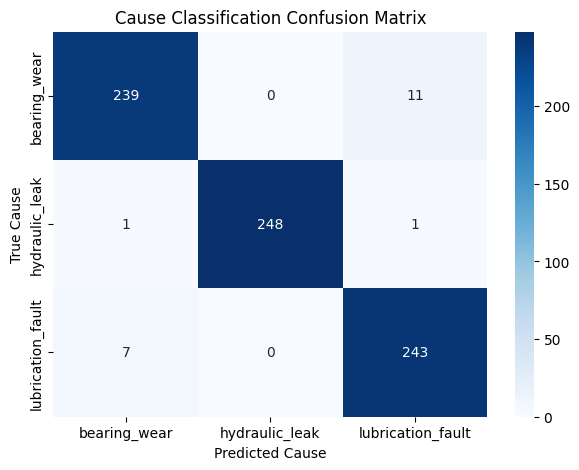

In [70]:
# ===================================================
# 12. 원인분류 모델 학습 (이상 데이터 기반)
# ===================================================

# 이상 데이터 프레임 정의
abnormal_df = df_feat[df_feat.is_abnormal==1]
# 이상 데이터 중 치명 인자만 입력 변수로 선택
X_cause = abnormal_df[critical_cols]
# 이상 데이터의 고장 유형을 fault_type에 있는 항목으로 정답 라벨로서 사용
y_cause = abnormal_df.fault_type

# 학습용/평가용 데이터 분리 (75%:25%), stratify로 고장 유형 비율을 양쪽에 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(X_cause, y_cause, test_size=0.25, random_state=42, stratify=y_cause)
# 원인 분류 모델 정의 (랜덤 포레스트 사용)
cause_model = RandomForestClassifier(n_estimators=400, max_depth=None, random_state=42)
# 원인 분류 모델 학습
cause_model.fit(X_train, y_train)

# 학습하지 않은 X_test 데이터를 가지고 고장 원인 예측
y_pred = cause_model.predict(X_test)
# 학습한 데이터 성능 검증 (고장 원인 분류 성능 출력)
print(classification_report(y_test, y_pred))

# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred, labels=cause_model.classes_)

# 그래프 출력
plt.figure(figsize=(7,5))
sns.heatmap(
    cm, # 계산된 confusion matrix
    annot=True, 
    fmt="d",
    xticklabels=cause_model.classes_,
    yticklabels=cause_model.classes_,
    cmap= "Blues"
)
plt.title("Cause Classification Confusion Matrix")
plt.xlabel("Predicted Cause")
plt.ylabel("True Cause")
plt.show()

lubrication_degradation_index    0.364600
hydraulic_efficiency_index       0.198829
vibration_load_index             0.172385
mechanical_friction_index        0.144738
energy_loss_index                0.062141
thermal_stress_index             0.046710
pressure_flow_balance            0.010597
dtype: float64


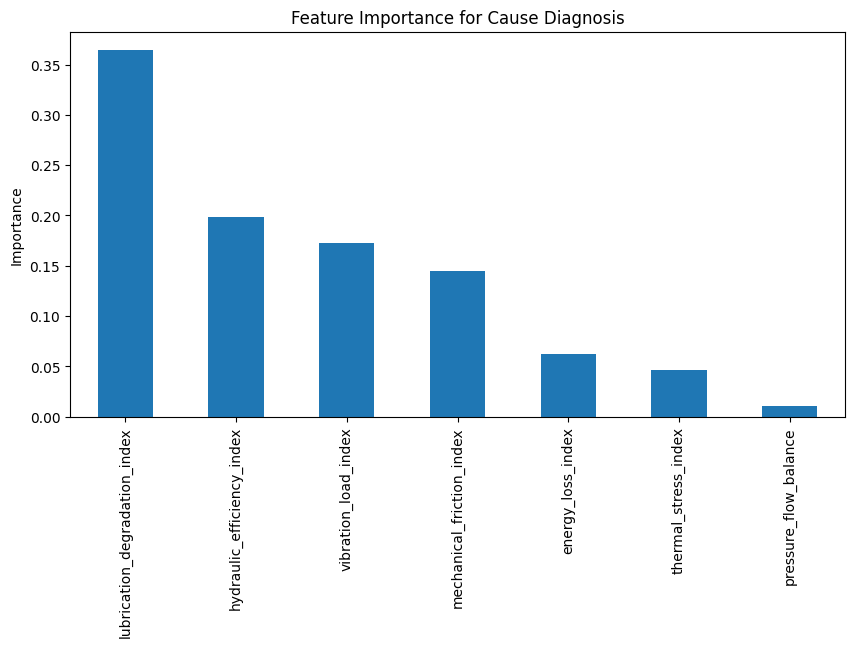

In [73]:
# ===================================================
# 13. 원인 분류 변수 중요도 확인
# ===================================================

# 원인분류 모델의 결과를 기반으로 변수 중요도 계산.
cause_importance = pd.Series(cause_model.feature_importances_, index=critical_cols).sort_values(ascending=False)
print(cause_importance)

plt.figure(figsize=(10,5))
cause_importance.plot(kind="bar")
plt.title("Feature Importance for Cause Diagnosis")
plt.ylabel("Importance")
plt.show()

In [76]:
# ===================================================
# 14. 신규 데이터 생성 및 테스트
# ===================================================

# 신규 샘플 데이터 생성 (시나리오)
# 1번: 베어링 마모 의심되는 샘플
# 2번: 유압 누설 의심되는 샘플
# 3번: 윤활 불량 의심되는 샘플 
new_data = pd.DataFrame([{
        "rpm": 1480,
        "load": 70,
        "pressure": 118,
        "temp": 69,
        "vibration": 2.7,
        "current": 27,
        "oil_viscosity": 41,
        "flow_rate": 78,
        "noise_1": 0.2,
        "noise_2": 11,
        "noise_3": 50,
    }, {
        "rpm": 1510,
        "load": 63,
        "pressure": 92,
        "temp": 58,
        "vibration": 1.5,
        "current": 25,
        "oil_viscosity": 43,
        "flow_rate": 60,
        "noise_1": -0.4,
        "noise_2": 9,
        "noise_3": 20,
    }, {
        "rpm": 1495,
        "load": 67,
        "pressure": 121,
        "temp": 66,
        "vibration": 2.1,
        "current": 25,
        "oil_viscosity": 28,
        "flow_rate": 79,
        "noise_1": 0.1,
        "noise_2": 12,
        "noise_3": 700,
    }
])

# 기존 파생변수 생성 함수를 활용하여 신규 데이터에 동일한 파생변수 생성 
# - 기존에 파생변수 생성했을 때처럼 타입을 맞춰 주어야 하기 때문
new_feat = add_critical_features(new_data)
# 파생변수 정상 기준 스케일러로 변환
new_scaled = scaler.transform(new_feat[critical_cols])
# 신규 데이터 이상점수 계산
new_score = -iso_model.decision_function(new_scaled)

# 신규 데이터에 이상 점수 추가
new_feat["anomaly_score"] = new_score
# 신규 데이터에 리스트 레벨 추가
new_feat["risk_level"] = new_feat.anomaly_score.apply(lambda x: classify_risk_level(x, warning_threshold, critical_threshold))
# 신규 데이터에 위험 등급 추가
new_feat["predicted_cause"] = "normal" # 기본값: normal로 설정

# Warning or Critical 데이터만 원인 분류 대상으로 선택 (NORMAL이 아닌 것)
abnormal_mask = new_feat.risk_level != "NORMAL"
# [중요] 이상으로 판단된 신규 데이터에 대해서만 고장 원인 예측 수행하도록 설정
new_feat.loc[abnormal_mask, "predicted_cause"] = cause_model.predict(new_feat.loc[abnormal_mask, critical_cols])
# 최종 진단 결과 출력
print(new_feat[critical_cols+["anomaly_score", "risk_level", "predicted_cause"]])

   thermal_stress_index  vibration_load_index  hydraulic_efficiency_index  ...  anomaly_score  risk_level    predicted_cause
0              1.257934                 189.0                  328.714286  ...       0.161728    CRITICAL       bearing_wear
1              0.959629                  94.5                  212.307692  ...       0.022780    CRITICAL     hydraulic_leak
2              1.102941                 140.7                  367.653846  ...       0.136110    CRITICAL  lubrication_fault

[3 rows x 10 columns]


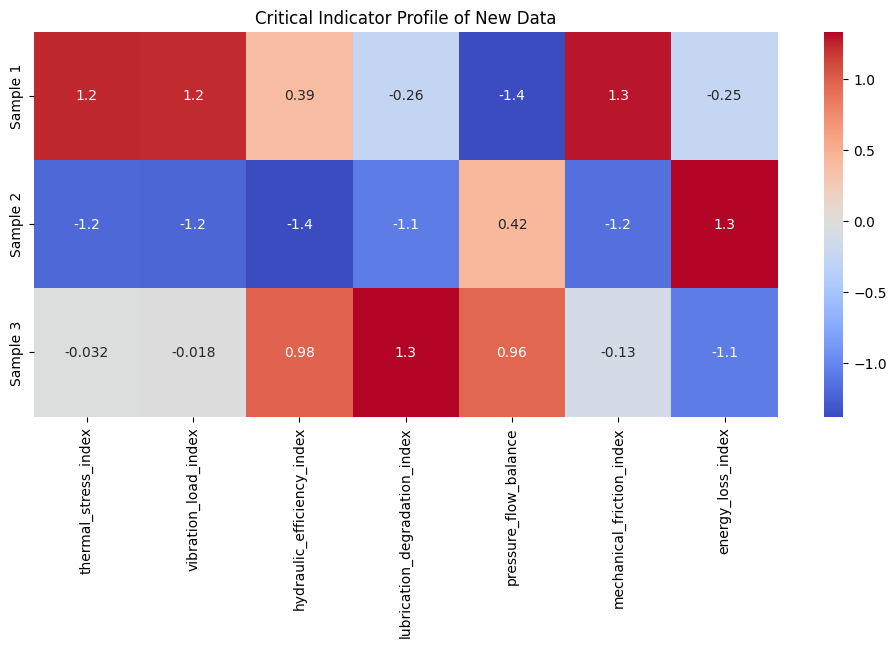

In [77]:
# ===================================================
# 15. 신규 데이터 원인 별 치명 인자 프로파일 시각화
# ===================================================

# 신규 데이터의 치명 인자만 복사해둔다.
new_profile = new_feat[critical_cols].copy()
# 
new_profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(new_profile),
    columns=critical_cols
)

# 히트맵으로 시각화
plt.figure(figsize=(12,5))
sns.heatmap(
    new_profile_scaled, 
    annot=True, 
    cmap="coolwarm", 
    xticklabels=critical_cols, 
    yticklabels=[f"Sample {i+1}" for i in range(len(new_feat))]
)
plt.title("Critical Indicator Profile of New Data")
plt.show()